In [1]:
# IPython extension to reload modules before executing user code.
# useful to see immediate results in notebook when modifying imported scripts
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os


# Add the ../py directory to sys.path
# This allows importing modules from the py directory as if they were in the current directory
module_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'py'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Verify it works
print(f"Added to path: {module_path}")

Added to path: /Users/eyal/projects/elzurdo/dpitg/py


In [3]:
from utils import print_env_info

from utils_viz import (
    FIG_WIDTH,
    FIG_HEIGHT,
    SMALL_SIZE,
    MEDIUM_SIZE,
    BIGGER_SIZE,
    plot_decision_rates_nhst,
)


from utils_experiments_binomial import (
    BinaryPvalueAccounting,
    BinomialSimulation,
    stop_decision_multiple_experiments_nhst,
    # BinomialHypothesis, 
    # run_simulations_and_analysis_report,
    # CI_FRACTION,
    )

from utils_experiments_shared import (
    SEED,
    #report_success_rates_multiple_algos
)

In [4]:
print_env_info()

Last run: 2026-07-30 11:24:30.641371
Python: 3.10.13
Platform: macOS-13.0-x86_64-i386-64bit
pandas: 2.3.3
numpy: 2.2.6
scipy: 1.15.3
matplotlib: 3.10.9
notebook: 7.6.0


In [5]:
plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["figure.figsize"] = FIG_WIDTH, FIG_HEIGHT
# plt.rcParams["hatch.linewidth"] = 0.2

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Aux

In [6]:
# used for storing an linking to binary calucations already performed
binary_pvalue_accounting = BinaryPvalueAccounting()
binary_pvalue_accounting.load_or_create()

Filepath for BinaryPvalueAccounting: cache/binary_pvalue_accounting_0pt5_two_sided.pkl
Loaded cache: 1,183 entries from cache/binary_pvalue_accounting_0pt5_two_sided.pkl


# Simulations

In [7]:
θ_true = 0.5

In [64]:
N_EXPERIMENTS = 200 # 2000
N_SAMPLES = 30000 #30000 #1500  # in paper called M

In [65]:
%%time

# was called synth_0pt5
sequences_0pt5 = BinomialSimulation(
    success_rate=θ_true,
    n_samples = N_SAMPLES,
    n_experiments = N_EXPERIMENTS,
    seed=SEED)

Generating synthetic data with parameter values:
0.5: true success rate
200: experiments
30000: sample size per experiment
CPU times: user 136 ms, sys: 18.4 ms, total: 154 ms
Wall time: 158 ms


# Hypothesis

In [66]:
θ_null = 0.5

# p-value False Positive Rate threshold
αfpr = 0.05

In [67]:
%%time

hypo_0pt5_results = stop_decision_multiple_experiments_nhst(
experiments= sequences_0pt5.experiments,
p_value_thresh= αfpr,
success_rate_null= θ_null,
alternative= 'two-sided',
binary_pvalue_accounting= binary_pvalue_accounting,
) 

hypo_0pt5_results.keys()

CPU times: user 11min 16s, sys: 3.8 s, total: 11min 20s
Wall time: 11min 26s


dict_keys(['iteration_stopping_on_or_prior', 'experiment_stop_results'])

In [68]:
binary_pvalue_accounting.save()

Cache saved: 1,941,229 entries to cache/binary_pvalue_accounting_0pt5_two_sided.pkl


# Results

In [69]:
df_experiment_stats = pd.DataFrame(hypo_0pt5_results['experiment_stop_results'])
df_experiment_stats.index.name = 'experiment_number'
df_experiment_stats['sample_success_rate'] = df_experiment_stats['successes'] * 1. / df_experiment_stats['trials']

print(df_experiment_stats.shape)
df_experiment_stats.head(4)

(200, 4)


,successes,trials,p_value,sample_success_rate
experiment_number,,,,
0,15010,30000,0.912650,0.500333
1,14999,30000,0.995393,0.499967
2,19,54,0.040224,0.351852
3,9,30,0.042774,0.300000


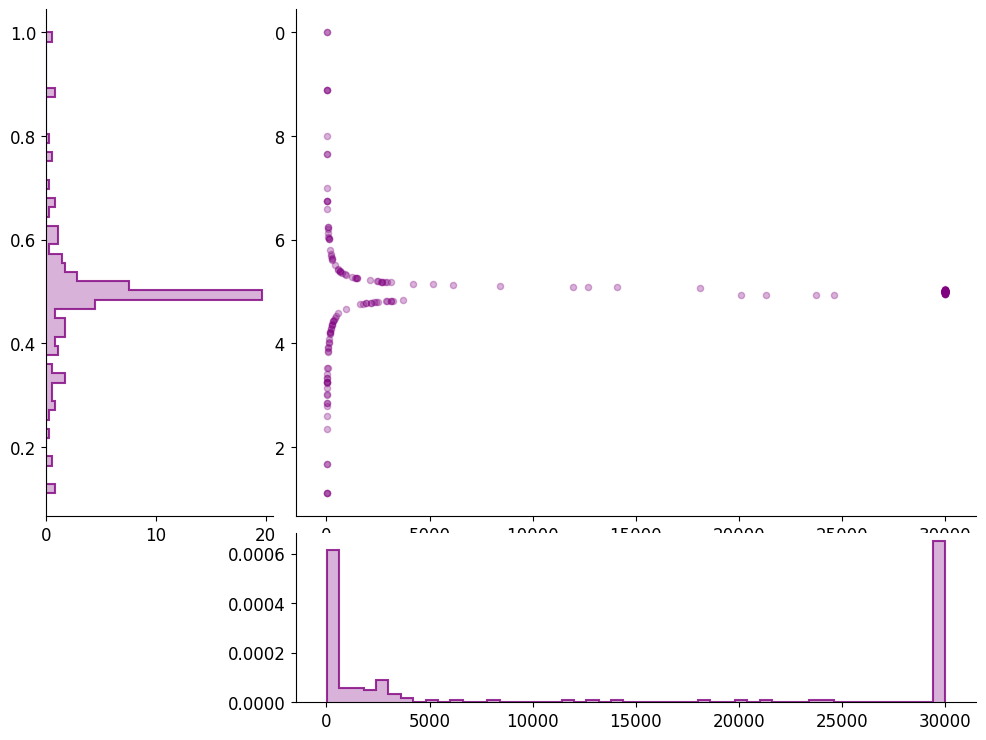

In [70]:
import matplotlib.gridspec as gridspec

scatter_ratio = 3

fig = plt.figure(figsize=(FIG_WIDTH * 1.5, FIG_HEIGHT * 1.5))

gs = gridspec.GridSpec(2, 2, width_ratios=[1, scatter_ratio], height_ratios=[scatter_ratio, 1], 
                        wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[0, 0], sharey=ax_scatter)
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_scatter)


color = "purple"
ax_scatter.scatter(df_experiment_stats["trials"], df_experiment_stats["sample_success_rate"], 
                           alpha=0.3, color=color, label=None, marker=None, s=20)


# --- Bottom Panel: Iteration Histogram ---
# Calculate histogram first to capture densities
bins = 50
iter_counts, iter_bins = np.histogram(df_experiment_stats["trials"], bins=bins, density=True)
#iteration_max_densities.append(np.max(iter_counts))

ax_bottom.hist(df_experiment_stats["trials"], bins=bins, color=color, alpha=0.3, 
                density=True, histtype='stepfilled')
ax_bottom.hist(df_experiment_stats["trials"], bins=bins, color=color, alpha=0.8, 
                density=True, histtype='step', linewidth=1.5)


# --- Left Panel: Success Rate Histogram ---
success_counts, success_bins = np.histogram(df_experiment_stats["sample_success_rate"], bins=bins, density=True)


ax_left.hist(df_experiment_stats["sample_success_rate"], bins=bins, color=color, alpha=0.3, 
                density=True, histtype='stepfilled', orientation='horizontal')
ax_left.hist(df_experiment_stats["sample_success_rate"], bins=bins, color=color, alpha=0.8, 
                density=True, histtype='step', orientation='horizontal', linewidth=1.5)
pass

Saved figure to ./figures/png/faircoin_decision_rates_nhst_dpi350.png
Saved figure to ./figures/tiff/faircoin_decision_rates_nhst_dpi350.tiff


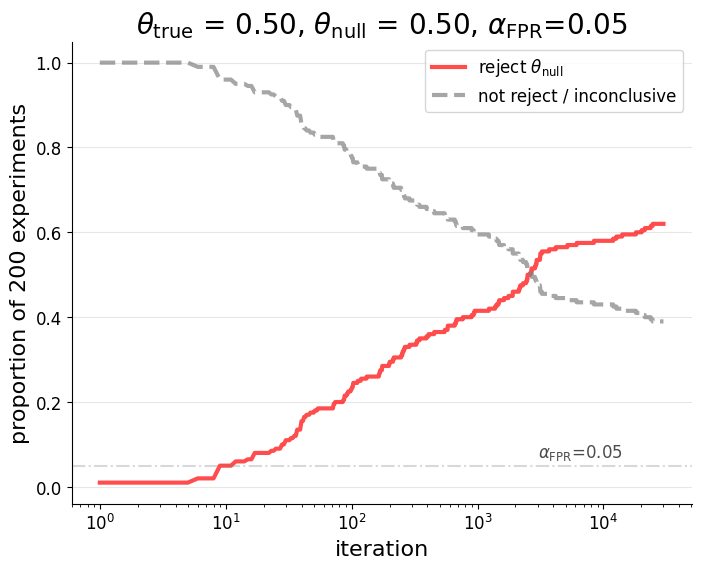

In [71]:
plot_decision_rates_nhst(N_EXPERIMENTS, hypo_0pt5_results['iteration_stopping_on_or_prior'],
 fpr=αfpr, success_rate_true=θ_true, success_rate_null=θ_null, filename="faircoin_decision_rates_nhst")